In [ ]:
!pip install understatapi pandas --quiet

In [ ]:
import pandas as pd
import understatapi

client = understatapi.UnderstatClient()

league = client.league(league='EPL')
matches = league.get_match_data(season='2026')

df = pd.DataFrame(matches)

In [ ]:
shot_data = client.match(match='31209').get_shot_data()
shot_data

{'h': [{'id': '693055',
   'minute': '4',
   'result': 'SavedShot',
   'X': '0.9369999694824219',
   'Y': '0.4209999847412109',
   'xG': '0.4750669598579407',
   'player': 'Riccardo Calafiori',
   'h_a': 'h',
   'player_id': '8129',
   'situation': 'SetPiece',
   'season': '2026',
   'shotType': 'RightFoot',
   'match_id': '31209',
   'h_team': 'Arsenal',
   'a_team': 'Chelsea',
   'h_goals': '2',
   'a_goals': '1',
   'date': '2026-09-06 15:30:00',
   'player_assisted': 'Martin Odegaard',
   'lastAction': 'Pass'},
  {'id': '693056',
   'minute': '4',
   'result': 'SavedShot',
   'X': '0.960999984741211',
   'Y': '0.4229999923706055',
   'xG': '0.1343599408864975',
   'player': 'Gabriel',
   'h_a': 'h',
   'player_id': '5613',
   'situation': 'SetPiece',
   'season': '2026',
   'shotType': 'RightFoot',
   'match_id': '31209',
   'h_team': 'Arsenal',
   'a_team': 'Chelsea',
   'h_goals': '2',
   'a_goals': '1',
   'date': '2026-09-06 15:30:00',
   'player_assisted': None,
   'lastAction

In [ ]:
type(shot_data)

dict

In [ ]:
shot_data.keys()

dict_keys(['h', 'a'])

In [ ]:
import pandas as pd

df = pd.DataFrame(shot_data['h'] + shot_data['a'])

df[['X','Y','xG','minute']] = df[['X','Y','xG','minute']].astype(float)

df.head()

,id,minute,result,X,Y,xG,player,h_a,player_id,situation,season,shotType,match_id,h_team,a_team,h_goals,a_goals,date,player_assisted,lastAction
0,693055,4.0,SavedShot,0.937,0.421,0.475067,Riccardo Calafiori,h,8129,SetPiece,2026,RightFoot,31209,Arsenal,Chelsea,2,1,2026-09-06 15:30:00,Martin Odegaard,Pass
1,693056,4.0,SavedShot,0.961,0.423,0.134360,Gabriel,h,5613,SetPiece,2026,RightFoot,31209,Arsenal,Chelsea,2,1,2026-09-06 15:30:00,None,Rebound
2,693057,11.0,SavedShot,0.965,0.581,0.521602,Gabriel,h,5613,SetPiece,2026,RightFoot,31209,Arsenal,Chelsea,2,1,2026-09-06 15:30:00,None,None
3,693058,14.0,SavedShot,0.958,0.562,0.067626,Kai Havertz,h,5220,OpenPlay,2026,Head,31209,Arsenal,Chelsea,2,1,2026-09-06 15:30:00,Martin Odegaard,Aerial
4,693059,17.0,SavedShot,0.963,0.315,0.300861,Bukayo Saka,h,7322,OpenPlay,2026,RightFoot,31209,Arsenal,Chelsea,2,1,2026-09-06 15:30:00,Martin Odegaard,Throughball


In [ ]:
print(df.columns)

Index(['id', 'minute', 'result', 'X', 'Y', 'xG', 'player', 'h_a', 'player_id',
       'situation', 'season', 'shotType', 'match_id', 'h_team', 'a_team',
       'h_goals', 'a_goals', 'date', 'player_assisted', 'lastAction'],
      dtype='object')


In [ ]:
print(df[['X','Y']].head())

       X      Y
0  0.937  0.421
1  0.961  0.423
2  0.965  0.581
3  0.958  0.562
4  0.963  0.315


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               29 non-null     object 
 1   minute           29 non-null     float64
 2   result           29 non-null     object 
 3   X                29 non-null     float64
 4   Y                29 non-null     float64
 5   xG               29 non-null     float64
 6   player           29 non-null     object 
 7   h_a              29 non-null     object 
 8   player_id        29 non-null     object 
 9   situation        29 non-null     object 
 10  season           29 non-null     object 
 11  shotType         29 non-null     object 
 12  match_id         29 non-null     object 
 13  h_team           29 non-null     object 
 14  a_team           29 non-null     object 
 15  h_goals          29 non-null     object 
 16  a_goals          29 non-null     object 
 17  date             2

# STEP 1 — Clean numeric columns properly

In [ ]:
import pandas as pd

num_cols = [
    'minute',
    'X',
    'Y',
    'xG',
    'h_goals',
    'a_goals'
]

df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')

# STEP 2 — Fix player_id (important for player analysis)

In [ ]:
df['player_id'] = pd.to_numeric(df['player_id'], errors='coerce')

In [ ]:
df['shot_quality'] = pd.cut(
    df['xG'],
    bins=[0, 0.1, 0.3, 1],
    labels=['Low', 'Medium', 'High']
)

In [ ]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   id               29 non-null     object  
 1   minute           29 non-null     float64 
 2   result           29 non-null     object  
 3   X                29 non-null     float64 
 4   Y                29 non-null     float64 
 5   xG               29 non-null     float64 
 6   player           29 non-null     object  
 7   h_a              29 non-null     object  
 8   player_id        29 non-null     int64   
 9   situation        29 non-null     object  
 10  season           29 non-null     object  
 11  shotType         29 non-null     object  
 12  match_id         29 non-null     object  
 13  h_team           29 non-null     object  
 14  a_team           29 non-null     object  
 15  h_goals          29 non-null     int64   
 16  a_goals          29 non-null     int64   
 17 

,id,minute,result,X,Y,xG,player,h_a,player_id,situation,...,shotType,match_id,h_team,a_team,h_goals,a_goals,date,player_assisted,lastAction,shot_quality
0,693055,4.0,SavedShot,0.937,0.421,0.475067,Riccardo Calafiori,h,8129,SetPiece,...,RightFoot,31209,Arsenal,Chelsea,2,1,2026-09-06 15:30:00,Martin Odegaard,Pass,High
1,693056,4.0,SavedShot,0.961,0.423,0.134360,Gabriel,h,5613,SetPiece,...,RightFoot,31209,Arsenal,Chelsea,2,1,2026-09-06 15:30:00,None,Rebound,Medium
2,693057,11.0,SavedShot,0.965,0.581,0.521602,Gabriel,h,5613,SetPiece,...,RightFoot,31209,Arsenal,Chelsea,2,1,2026-09-06 15:30:00,None,None,High
3,693058,14.0,SavedShot,0.958,0.562,0.067626,Kai Havertz,h,5220,OpenPlay,...,Head,31209,Arsenal,Chelsea,2,1,2026-09-06 15:30:00,Martin Odegaard,Aerial,Low
4,693059,17.0,SavedShot,0.963,0.315,0.300861,Bukayo Saka,h,7322,OpenPlay,...,RightFoot,31209,Arsenal,Chelsea,2,1,2026-09-06 15:30:00,Martin Odegaard,Throughball,High


# Total Shot per Team

In [ ]:
df.groupby('h_a')['shotType'].count()

,shotType
h_a,
a,13
h,16


# Average Shot Distance

In [ ]:
df.groupby('h_a')[['X','Y']].mean()

,X,Y
h_a,,
a,0.798462,0.488000
h,0.884813,0.477875


# Average distance to goal

In [ ]:
import numpy as np

# Assuming goal is at x=100, y=50
df['distance_to_goal'] = np.sqrt((df['X'])**2 + (df['Y'] - 50)**2)

df.groupby('h_a')['distance_to_goal'].mean()

,distance_to_goal
h_a,
a,49.518498
h,49.530065


In [ ]:
df.groupby(['h_a', 'result']).size().unstack(fill_value=0)

result,BlockedShot,Goal,MissedShots,SavedShot,ShotOnPost
h_a,,,,,
a,2,1,5,4,1
h,6,2,1,7,0


# shots efficiency

In [ ]:
import pandas as pd

# Sample data
data = {
    'h_a': ['a', 'h'],
    'BlockedShot': [2, 6],
    'MissedShots': [5, 1],
    'SavedShot': [4, 7],
    'ShotOnPost': [1, 0],
    'goal': [1, 2]
}

df = pd.DataFrame(data)

# Set index correctly
df.set_index('h_a', inplace=True)

# Calculate total shots (only shot columns)
df['total_shots'] = df[['BlockedShot', 'MissedShots', 'ShotOnPost', 'SavedShot', 'goal']].sum(axis=1)

# Shots on target = saved shots + goals
df['shots_on_target'] = df['SavedShot'] + df['goal']

# Shooting accuracy %
df['shooting_accuracy'] = (
    df['shots_on_target'] / df['total_shots'] * 100
).round(2)

print(df[['total_shots', 'shots_on_target', 'shooting_accuracy']])

     total_shots  shots_on_target  shooting_accuracy
h_a                                                 
a             13                5              38.46
h             16                9              56.25


# Create a Goal Column

In [ ]:
import pandas as pd

# Create a dedicated dataframe from the raw Understat shot data
shots_df = pd.DataFrame(shot_data['h'] + shot_data['a'])

# Convert numerical columns
shots_df[['X', 'Y', 'xG', 'minute']] = (
    shots_df[['X', 'Y', 'xG', 'minute']].astype(float)
)

# Create goal indicator
shots_df['is_goal'] = (
    shots_df['result'] == 'Goal'
).astype(int)

print(shots_df[['result', 'is_goal']].head())

      result  is_goal
0  SavedShot        0
1  SavedShot        0
2  SavedShot        0
3  SavedShot        0
4  SavedShot        0


In [ ]:
shots_df["is_goal"] = (shots_df["result"] == "Goal").astype(int)

In [ ]:
total_shots = len(shots_df)

total_xg = shots_df["xG"].sum()

total_goals = shots_df["is_goal"].sum()
print("Total Shots:", total_shots)
print("Total xG:", round(total_xg, 2))
print("Total Goals:", total_goals)

Total Shots: 29
Total xG: 3.3
Total Goals: 3


In [ ]:
team_summary = shots_df.groupby("h_a").agg(
    total_shots=("id", "count"),
    total_xG=("xG", "sum"),
    total_goals=("is_goal", "sum")
)

print(team_summary)

     total_shots  total_xG  total_goals
h_a                                    
a             13  0.430508            1
h             16  2.869379            2


# Player-Level Efficiency

In [ ]:
player_stats = shots_df.groupby("player").agg(
    shots=("id", "count"),
    xG=("xG", "sum"),
    goals=("is_goal", "sum")
).reset_index()

player_stats["xG_per_shot"] = (
    player_stats["xG"] / player_stats["shots"]
)

player_stats["finishing_diff"] = (
    player_stats["goals"] - player_stats["xG"]
)

player_stats.sort_values(
    "finishing_diff",
    ascending=False
).head(10)

,player,shots,xG,goals,xG_per_shot,finishing_diff
10,Morgan Rogers,3,0.109345,1,0.036448,0.890655
6,Kai Havertz,3,0.198472,1,0.066157,0.801528
8,Martin Odegaard,2,0.688309,1,0.344154,0.311691
5,João Pedro,1,0.016263,0,0.016263,-0.016263
3,Estêvão,1,0.029690,0,0.029690,-0.029690
7,Malo Gusto,1,0.038223,0,0.038223,-0.038223
2,Declan Rice,1,0.042860,0,0.042860,-0.042860
13,Reece James,3,0.059830,0,0.019943,-0.059830
11,Myles Lewis-Skelly,1,0.063163,0,0.063163,-0.063163
1,Cole Palmer,3,0.079329,0,0.026443,-0.079329


# Shot Type Analysis

In [ ]:
shot_type_analysis = shots_df.groupby("situation").agg(
    shots=("id", "count"),
    xG=("xG", "mean")
).sort_values("xG", ascending=False)

shot_type_analysis

,shots,xG
situation,,
SetPiece,4,0.291925
OpenPlay,23,0.090746
DirectFreekick,1,0.032327
FromCorner,1,0.012704


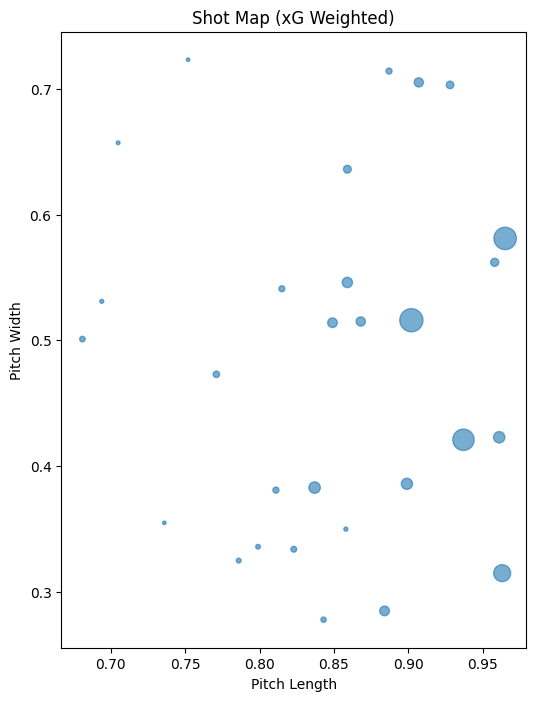

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 8))

plt.scatter(shots_df["X"], shots_df["Y"],
            s=shots_df["xG"] * 500,
            alpha=0.6)

plt.title("Shot Map (xG Weighted)")
plt.xlabel("Pitch Length")
plt.ylabel("Pitch Width")
plt.show()

In [ ]:
player_stats = shots_df.groupby("player").agg(
    shots=("id", "count"),
    xG=("xG", "sum"),
    goals=("is_goal", "sum")
).reset_index()

player_stats["finishing_diff"] = player_stats["goals"] - player_stats["xG"]
player_stats["xG_per_shot"] = player_stats["xG"] / player_stats["shots"]

In [ ]:
player_stats.head()

,player,shots,xG,goals,finishing_diff,xG_per_shot
0,Bukayo Saka,4,0.546873,0,-0.546873,0.136718
1,Cole Palmer,3,0.079329,0,-0.079329,0.026443
2,Declan Rice,1,0.042860,0,-0.042860,0.042860
3,Estêvão,1,0.029690,0,-0.029690,0.029690
4,Gabriel,2,0.655962,0,-0.655962,0.327981


# Top Overperformers (Clinical Finishers)

In [ ]:
player_stats.sort_values("finishing_diff", ascending=False).head(5)

,player,shots,xG,goals,finishing_diff,xG_per_shot
10,Morgan Rogers,3,0.109345,1,0.890655,0.036448
6,Kai Havertz,3,0.198472,1,0.801528,0.066157
8,Martin Odegaard,2,0.688309,1,0.311691,0.344154
5,João Pedro,1,0.016263,0,-0.016263,0.016263
3,Estêvão,1,0.029690,0,-0.029690,0.029690


# Underperformers (Wasteful or Unlucky)

In [ ]:
player_stats.sort_values("finishing_diff").head(5)

,player,shots,xG,goals,finishing_diff,xG_per_shot
4,Gabriel,2,0.655962,0,-0.655962,0.327981
14,Riccardo Calafiori,2,0.563355,0,-0.563355,0.281678
0,Bukayo Saka,4,0.546873,0,-0.546873,0.136718
9,Martín Zubimendi,1,0.110386,0,-0.110386,0.110386
12,Pedro Neto,1,0.097828,0,-0.097828,0.097828


# Home vs Away Shot Quality

In [ ]:
home_away = shots_df.groupby("h_a").agg(
    shots=("id", "count"),
    xG=("xG", "sum"),
    goals=("is_goal", "sum")
).reset_index()

home_away["xG_per_shot"] = home_away["xG"] / home_away["shots"]
home_away

,h_a,shots,xG,goals,xG_per_shot
0,a,13,0.430508,1,0.033116
1,h,16,2.869379,2,0.179336


# Player Impact Profile

In [ ]:
impact = player_stats.copy()

impact["goal_conversion_rate"] = impact["goals"] / impact["shots"]
impact["xG_per_shot"] = impact["xG"] / impact["shots"]

impact.sort_values("xG", ascending=False).head(10)

,player,shots,xG,goals,finishing_diff,xG_per_shot,goal_conversion_rate
8,Martin Odegaard,2,0.688309,1,0.311691,0.344154,0.500000
4,Gabriel,2,0.655962,0,-0.655962,0.327981,0.000000
14,Riccardo Calafiori,2,0.563355,0,-0.563355,0.281678,0.000000
0,Bukayo Saka,4,0.546873,0,-0.546873,0.136718,0.000000
6,Kai Havertz,3,0.198472,1,0.801528,0.066157,0.333333
9,Martín Zubimendi,1,0.110386,0,-0.110386,0.110386,0.000000
10,Morgan Rogers,3,0.109345,1,0.890655,0.036448,0.333333
12,Pedro Neto,1,0.097828,0,-0.097828,0.097828,0.000000
1,Cole Palmer,3,0.079329,0,-0.079329,0.026443,0.000000
11,Myles Lewis-Skelly,1,0.063163,0,-0.063163,0.063163,0.000000


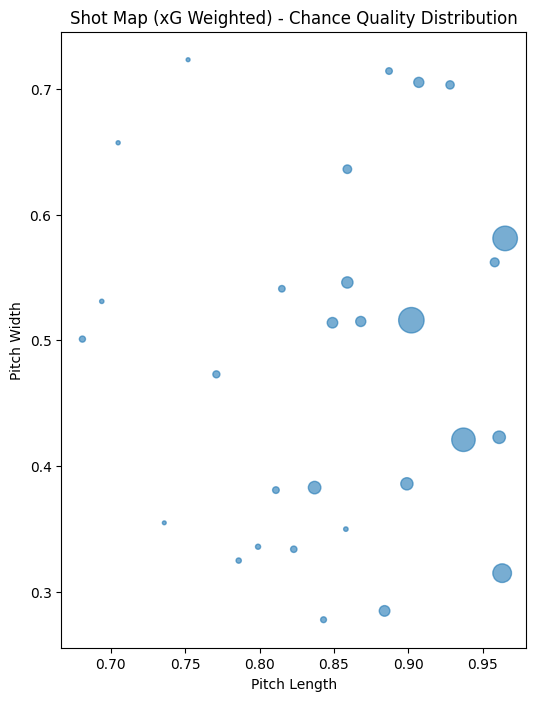

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 8))

plt.scatter(shots_df["X"], shots_df["Y"],
            s=shots_df["xG"] * 600,
            alpha=0.6)

plt.title("Shot Map (xG Weighted) - Chance Quality Distribution")
plt.xlabel("Pitch Length")
plt.ylabel("Pitch Width")
plt.show()

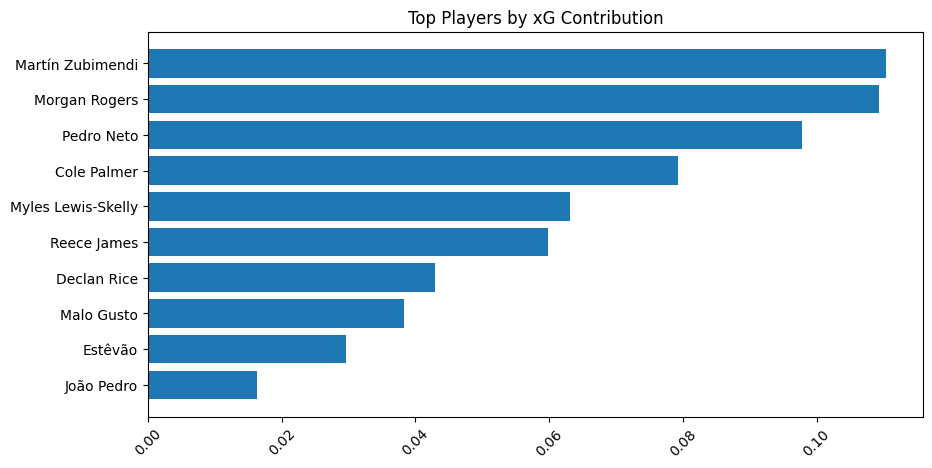

In [ ]:
top_players = player_stats.sort_values("xG", ascending=True).head(10)

plt.figure(figsize=(10, 5))
plt.barh(top_players["player"], top_players["xG"])
plt.title("Top Players by xG Contribution")
plt.xticks(rotation=45)
plt.show()

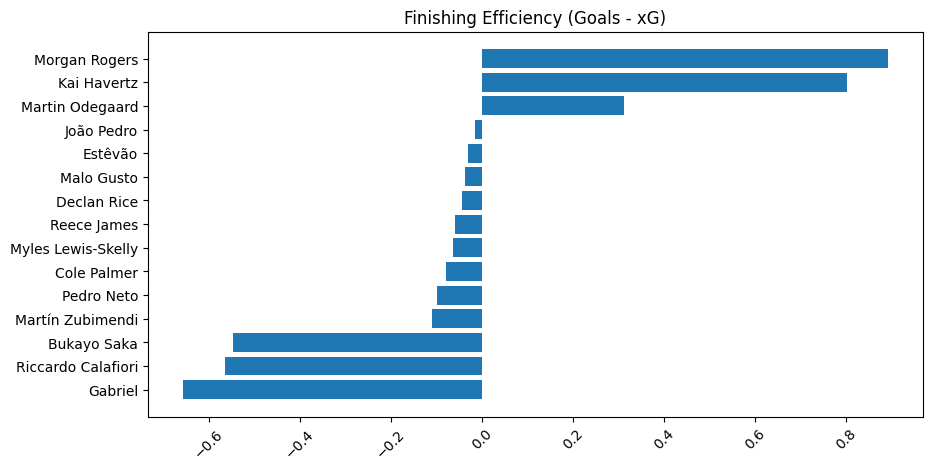

In [ ]:
eff_players = player_stats.sort_values("finishing_diff", ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(eff_players["player"], eff_players["finishing_diff"])
plt.title("Finishing Efficiency (Goals - xG)")
plt.xticks(rotation=45)
plt.show()

# Number of situation by player

In [ ]:
situation_counts= shots_df.groupby("player")["situation"].value_counts()
print(situation_counts)

player              situation     
Bukayo Saka         OpenPlay          4
Cole Palmer         OpenPlay          3
Declan Rice         OpenPlay          1
Estêvão             OpenPlay          1
Gabriel             SetPiece          2
João Pedro          OpenPlay          1
Kai Havertz         OpenPlay          3
Malo Gusto          OpenPlay          1
Martin Odegaard     OpenPlay          2
Martín Zubimendi    OpenPlay          1
Morgan Rogers       OpenPlay          2
                    SetPiece          1
Myles Lewis-Skelly  OpenPlay          1
Pedro Neto          OpenPlay          1
Reece James         DirectFreekick    1
                    FromCorner        1
                    OpenPlay          1
Riccardo Calafiori  OpenPlay          1
                    SetPiece          1
Name: count, dtype: int64


# Number of situation per Team

In [ ]:
situation_counts= shots_df.groupby("h_a")["situation"].value_counts()
print(situation_counts)

h_a  situation     
a    OpenPlay          10
     DirectFreekick     1
     FromCorner         1
     SetPiece           1
h    OpenPlay          13
     SetPiece           3
Name: count, dtype: int64


In [ ]:
shots_df.groupby("player",)["xG"].sum().sort_values(ascending=False)

,xG
player,
Martin Odegaard,0.688309
Gabriel,0.655962
Riccardo Calafiori,0.563355
Bukayo Saka,0.546873
Kai Havertz,0.198472
Martín Zubimendi,0.110386
Morgan Rogers,0.109345
Pedro Neto,0.097828
Cole Palmer,0.079329


# Team total Expected goals (xG)

In [ ]:
shots_df.groupby("h_a")["xG"].sum()

,xG
h_a,
a,0.430508
h,2.869379


# Total shots per player

In [ ]:
shots_per_player = shots_df.groupby("player").size().reset_index(name="Total_Shots")
print(shots_per_player)

                player  Total_Shots
0          Bukayo Saka            4
1          Cole Palmer            3
2          Declan Rice            1
3              Estêvão            1
4              Gabriel            2
5           João Pedro            1
6          Kai Havertz            3
7           Malo Gusto            1
8      Martin Odegaard            2
9     Martín Zubimendi            1
10       Morgan Rogers            3
11  Myles Lewis-Skelly            1
12          Pedro Neto            1
13         Reece James            3
14  Riccardo Calafiori            2


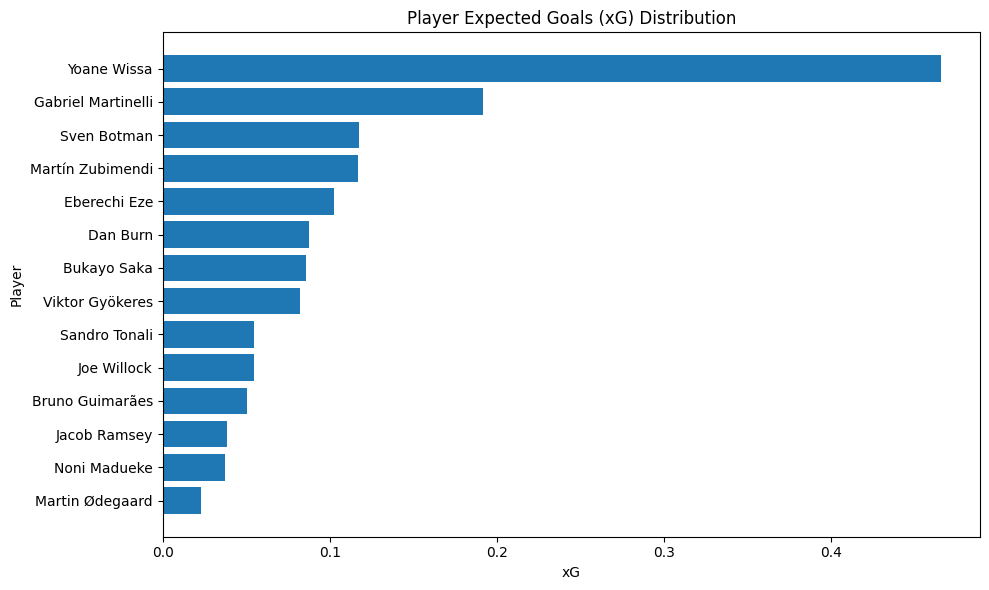

In [ ]:
import pandas as pd

data = pd.DataFrame({
    "player": [
        "Yoane Wissa",
        "Gabriel Martinelli",
        "Sven Botman",
        "Martín Zubimendi",
        "Eberechi Eze",
        "Dan Burn",
        "Bukayo Saka",
        "Viktor Gyökeres",
        "Sandro Tonali",
        "Joe Willock",
        "Bruno Guimarães",
        "Jacob Ramsey",
        "Noni Madueke",
        "Martin Ødegaard"
    ],
    "xG": [
        0.465772,
        0.191724,
        0.117720,
        0.116619,
        0.102621,
        0.087275,
        0.085591,
        0.082300,
        0.054937,
        0.054423,
        0.050200,
        0.038571,
        0.037115,
        0.023219
    ]
})

df_players = pd.DataFrame(data)

# Sort for better analysis (optional)
df_players = df_players.sort_values(by="xG", ascending=False)

import matplotlib.pyplot as plt

# Sort values
df_players_sorted = df_players.sort_values("xG", ascending=True)

plt.figure(figsize=(10,6))
plt.barh(df_players_sorted["player"], df_players_sorted["xG"])

plt.title("Player Expected Goals (xG) Distribution")
plt.xlabel("xG")
plt.ylabel("Player")

plt.tight_layout()
plt.show()

# Goals by body part

In [ ]:
shot_analysis = (
    shots_df.groupby('shotType')
    .agg(
        shots=('id', 'count'),
        goals=('result', lambda x: (x == 'Goal').sum())
    )
    .reset_index()
)

shot_analysis['goal_rate'] = shot_analysis['goals'] / shot_analysis['shots']
shot_analysis.sort_values('goal_rate', ascending=False)

,shotType,shots,goals,goal_rate
1,LeftFoot,12,2,0.166667
2,RightFoot,16,1,0.062500
0,Head,1,0,0.000000


# Shots by body part

In [ ]:
shots_df["shotType"].value_counts()

,count
shotType,
RightFoot,16
LeftFoot,12
Head,1


In [ ]:
shot_type_counts = shots_df.groupby(["player","result","situation"])["shotType"].value_counts()
print(shot_type_counts)

player              result       situation       shotType 
Bukayo Saka         BlockedShot  OpenPlay        LeftFoot     1
                    SavedShot    OpenPlay        LeftFoot     2
                                                 RightFoot    1
Cole Palmer         MissedShots  OpenPlay        LeftFoot     1
                    SavedShot    OpenPlay        LeftFoot     1
                                                 RightFoot    1
Declan Rice         BlockedShot  OpenPlay        RightFoot    1
Estêvão             SavedShot    OpenPlay        LeftFoot     1
Gabriel             SavedShot    SetPiece        RightFoot    2
João Pedro          MissedShots  OpenPlay        RightFoot    1
Kai Havertz         BlockedShot  OpenPlay        LeftFoot     1
                    Goal         OpenPlay        LeftFoot     1
                    SavedShot    OpenPlay        Head         1
Malo Gusto          MissedShots  OpenPlay        RightFoot    1
Martin Odegaard     BlockedShot  OpenPlay    

# Shot outcome per player and position

In [ ]:
shots_counts= shots_df.groupby(["h_a","player", "X","Y","xG"])["result"].value_counts().reset_index(name="shots")
print(shots_counts)

   h_a              player      X      Y        xG       result  shots
0    a         Cole Palmer  0.786  0.325  0.024130    SavedShot      1
1    a         Cole Palmer  0.858  0.350  0.017362    SavedShot      1
2    a         Cole Palmer  0.887  0.714  0.037837  MissedShots      1
3    a             Estêvão  0.843  0.278  0.029690    SavedShot      1
4    a          João Pedro  0.694  0.531  0.016263  MissedShots      1
5    a          Malo Gusto  0.811  0.381  0.038223  MissedShots      1
6    a       Morgan Rogers  0.752  0.723  0.013339  MissedShots      1
7    a       Morgan Rogers  0.815  0.541  0.036671         Goal      1
8    a       Morgan Rogers  0.928  0.703  0.059334  MissedShots      1
9    a          Pedro Neto  0.884  0.285  0.097828   ShotOnPost      1
10   a         Reece James  0.681  0.501  0.032327  BlockedShot      1
11   a         Reece James  0.705  0.657  0.014800    SavedShot      1
12   a         Reece James  0.736  0.355  0.012704  BlockedShot      1
13   h

In [ ]:
shots_counts= shots_df.groupby(["h_a","player", "X","Y","xG","situation"])["result"].value_counts().reset_index(name="shots")
print(shots_counts)

   h_a              player      X      Y        xG       situation  \
0    a         Cole Palmer  0.786  0.325  0.024130        OpenPlay   
1    a         Cole Palmer  0.858  0.350  0.017362        OpenPlay   
2    a         Cole Palmer  0.887  0.714  0.037837        OpenPlay   
3    a             Estêvão  0.843  0.278  0.029690        OpenPlay   
4    a          João Pedro  0.694  0.531  0.016263        OpenPlay   
5    a          Malo Gusto  0.811  0.381  0.038223        OpenPlay   
6    a       Morgan Rogers  0.752  0.723  0.013339        OpenPlay   
7    a       Morgan Rogers  0.815  0.541  0.036671        SetPiece   
8    a       Morgan Rogers  0.928  0.703  0.059334        OpenPlay   
9    a          Pedro Neto  0.884  0.285  0.097828        OpenPlay   
10   a         Reece James  0.681  0.501  0.032327  DirectFreekick   
11   a         Reece James  0.705  0.657  0.014800        OpenPlay   
12   a         Reece James  0.736  0.355  0.012704      FromCorner   
13   h         Bukay

In [ ]:
pip install mplsoccer

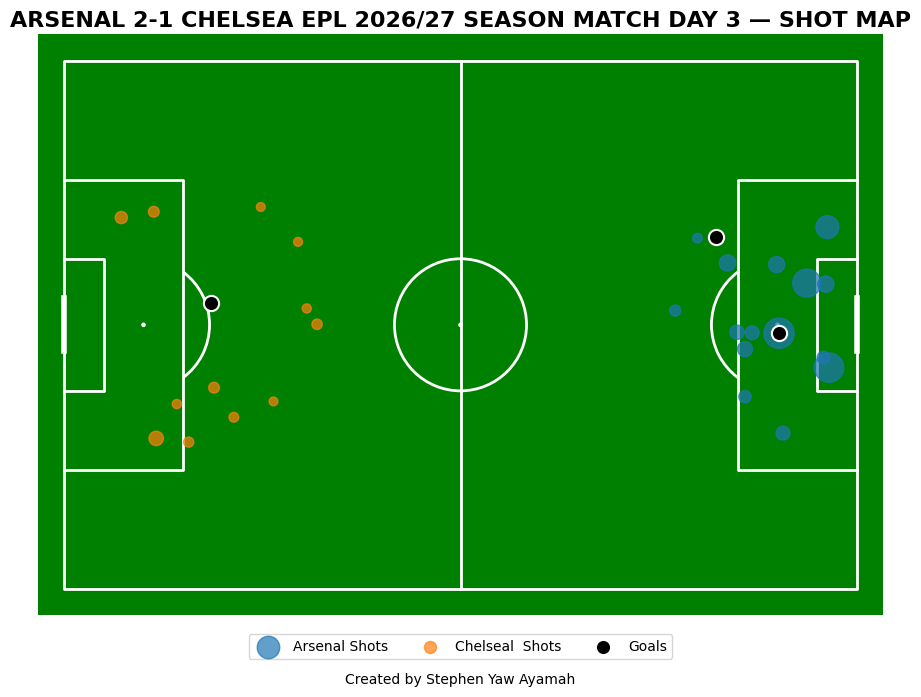

In [ ]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

# Create pitch
pitch = Pitch(
    pitch_type='statsbomb',
    pitch_color='green',
    line_color='white'
)

fig, ax = plt.subplots(figsize=(10, 7))
pitch.draw(ax=ax)

# Create a copy so we don't modify the original dataframe
shots = shots_df.copy()

# Convert normalized coordinates to StatsBomb pitch coordinates
shots['x'] = shots['X'] * 120
shots['y'] = shots['Y'] * 80

# Split teams
home = shots[shots['h_a'] == 'h'].copy()
away = shots[shots['h_a'] == 'a'].copy()

# Flip Coventry coordinates so both teams attack in the same direction
away['x'] = 120 - away['x']
away['y'] = 80 - away['y']

# Plot Arsenal shots
ax.scatter(
    home['x'],
    home['y'],
    s=home['xG'] * 800 + 30,
    alpha=0.7,
    label='Arsenal Shots'
)

# Plot Coventry shots
ax.scatter(
    away['x'],
    away['y'],
    s=away['xG'] * 800 + 30,
    alpha=0.7,
    label='Chelseal  Shots'
)

# Goals — IMPORTANT: use transformed coordinates
home_goals = home[home['result'] == 'Goal']
away_goals = away[away['result'] == 'Goal']

ax.scatter(
    home_goals['x'],
    home_goals['y'],
    c='black',
    s=120,
    edgecolors='white',
    linewidth=1.5,
    label='Goals'
)

ax.scatter(
    away_goals['x'],
    away_goals['y'],
    c='black',
    s=120,
    edgecolors='white',
    linewidth=1.5
)

plt.title(
    "ARSENAL 2-1 CHELSEA EPL 2026/27 SEASON MATCH DAY 3 — SHOT MAP",
    fontsize=16,
    fontweight='bold'
)

plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.02),
    ncol=3
)

# Creator credit
fig.text(
    0.5,
    0.02,
    "Created by Stephen Yaw Ayamah",
    ha="center",
    fontsize=10
)

plt.tight_layout(rect=[0, 0.04, 1, 1])

plt.show()

In [ ]:
shots_df.head()

,id,minute,result,X,Y,xG,player,h_a,player_id,situation,...,shotType,match_id,h_team,a_team,h_goals,a_goals,date,player_assisted,lastAction,is_goal
0,693055,4.0,SavedShot,0.937,0.421,0.475067,Riccardo Calafiori,h,8129,SetPiece,...,RightFoot,31209,Arsenal,Chelsea,2,1,2026-09-06 15:30:00,Martin Odegaard,Pass,0
1,693056,4.0,SavedShot,0.961,0.423,0.134360,Gabriel,h,5613,SetPiece,...,RightFoot,31209,Arsenal,Chelsea,2,1,2026-09-06 15:30:00,None,Rebound,0
2,693057,11.0,SavedShot,0.965,0.581,0.521602,Gabriel,h,5613,SetPiece,...,RightFoot,31209,Arsenal,Chelsea,2,1,2026-09-06 15:30:00,None,None,0
3,693058,14.0,SavedShot,0.958,0.562,0.067626,Kai Havertz,h,5220,OpenPlay,...,Head,31209,Arsenal,Chelsea,2,1,2026-09-06 15:30:00,Martin Odegaard,Aerial,0
4,693059,17.0,SavedShot,0.963,0.315,0.300861,Bukayo Saka,h,7322,OpenPlay,...,RightFoot,31209,Arsenal,Chelsea,2,1,2026-09-06 15:30:00,Martin Odegaard,Throughball,0


In [ ]:
understat_player = (
    shots_df
    .groupby("player")
    .agg(
        understat_shots=("id", "count"),
        understat_xG=("xG", "sum"),
        understat_goals=("is_goal", "sum")
    )
    .reset_index()
)

understat_player["understat_xG_per_shot"] = (
    understat_player["understat_xG"] /
    understat_player["understat_shots"]
)

understat_player["understat_finishing_diff"] = (
    understat_player["understat_goals"] -
    understat_player["understat_xG"]
)

In [ ]:
name_mapping = {
     "Martin Odegaard": "Martin Ødegaard"
}

understat_player["player"] = (
    understat_player["player"].replace(name_mapping)
)

In [ ]:
understat_player.to_csv(
    "Arsenal_Chelsea_understat_player_summary.csv",
    index=False
)

In [ ]:
from google.colab import files

files.download("Arsenal_Chelsea_understat_player_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>